In [50]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')



In [12]:
TICKERS = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]
START   = "2019-01-01"
END     = "2024-01-01"

raw = {}
for ticker in TICKERS:
    df = yf.download(ticker, start=START, end=END, auto_adjust=True)
    df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
    df.dropna(inplace=True)
    raw[ticker] = df
    print(f"{ticker}: {df.shape[0]} rows | {df.index[0].date()} to {df.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

RELIANCE.NS: 1235 rows | 2019-01-01 to 2023-12-29
TCS.NS: 1235 rows | 2019-01-01 to 2023-12-29
INFY.NS: 1235 rows | 2019-01-01 to 2023-12-29


In [56]:
raw

{'RELIANCE.NS':                   Close         High          Low         Open    Volume
 Date                                                                    
 2019-01-01   496.196381   498.985034   491.371654   498.077624   9746670
 2019-01-02   489.733917   498.852251   487.343655   493.319266  15628818
 2019-01-03   483.691925   493.363540   482.518940   490.220816  16288287
 2019-01-04   486.303436   488.870748   478.535167   485.750155  18516544
 2019-01-07   489.003510   495.067644   487.343608   489.999444  12060290
 ...                 ...          ...          ...          ...       ...
 2023-12-22  1267.243042  1275.073539  1258.646635  1264.550536  16541784
 2023-12-26  1273.665527  1280.532666  1266.081931  1268.700379   7465664
 2023-12-27  1278.013184  1284.460338  1271.220103  1275.617031   9204156
 2023-12-28  1287.251709  1290.438257  1278.013144  1279.470544  12302636
 2023-12-29  1277.074341  1291.426291  1274.283051  1289.993617  10864584
 
 [1235 rows x 5 colum

In [14]:
# Check one stock in detail
df = raw["RELIANCE.NS"]

print("=== Shape ===")
print(df.shape)

print("\n=== First 5 rows ===")
print(df.head())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
print(df.describe().round(2))

=== Shape ===
(1235, 5)

=== First 5 rows ===
                 Close        High         Low        Open    Volume
Date                                                                
2019-01-01  496.196381  498.985034  491.371654  498.077624   9746670
2019-01-02  489.733917  498.852251  487.343655  493.319266  15628818
2019-01-03  483.691925  493.363540  482.518940  490.220816  16288287
2019-01-04  486.303436  488.870748  478.535167  485.750155  18516544
2019-01-07  489.003510  495.067644  487.343608  489.999444  12060290

=== Missing Values ===
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

=== Basic Statistics ===
         Close     High      Low     Open        Volume
count  1235.00  1235.00  1235.00  1235.00  1.235000e+03
mean    932.74   943.31   923.05   933.55  2.079654e+07
std     239.36   240.45   238.17   239.35  1.611350e+07
min     393.66   423.03   389.92   407.98  1.705656e+06
25%     684.07   690.21   677.96   686.18  1.131555e+07
50%     993.

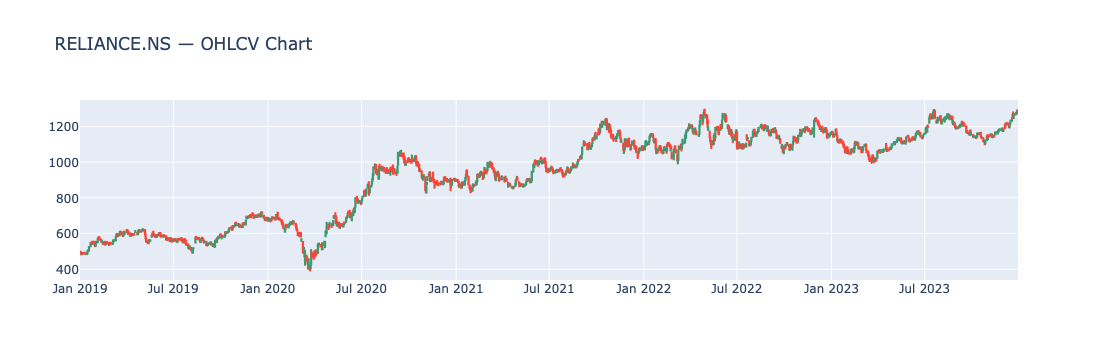

In [46]:
def candlestick_plot(df,ticker):
    fig=go.Figure()
    fig.add_trace(go.Candlestick(x=df.index,open=df['Open'], high=df['High'],low=df['Low'],close=df['Close'],name='Price'))
    fig.update_layout(
        title=f'{ticker} — OHLCV Chart',
        xaxis_rangeslider_visible=False,
    )
    fig.show()

candlestick_plot(raw["RELIANCE.NS"], "RELIANCE.NS")

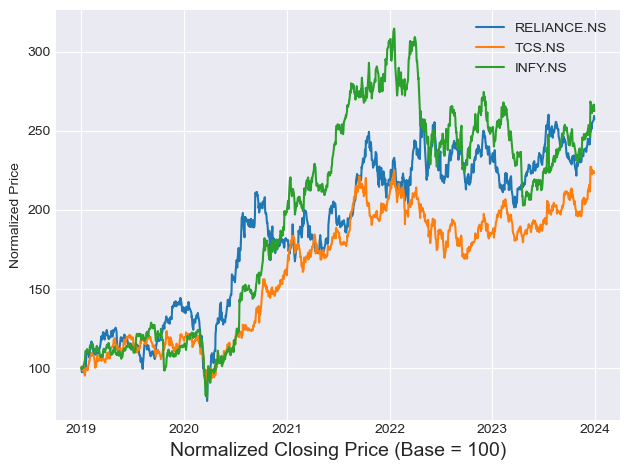

In [60]:
#closing price comparison 

for ticker, df in raw.items():
    # Normalize to 100 for fair comparison
    normalized = df['Close'] / df['Close'].iloc[0] * 100
    plt.plot(normalized, label=ticker)

plt.xlabel("Normalized Closing Price (Base = 100)", fontsize=14)
plt.ylabel("Normalized Price")
plt.legend()
plt.tight_layout()
plt.show()

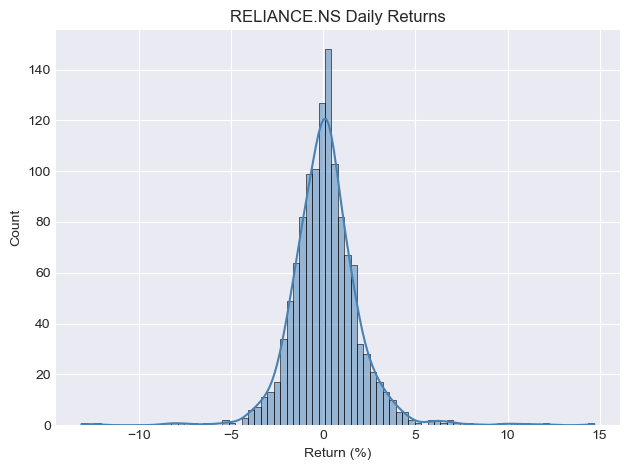

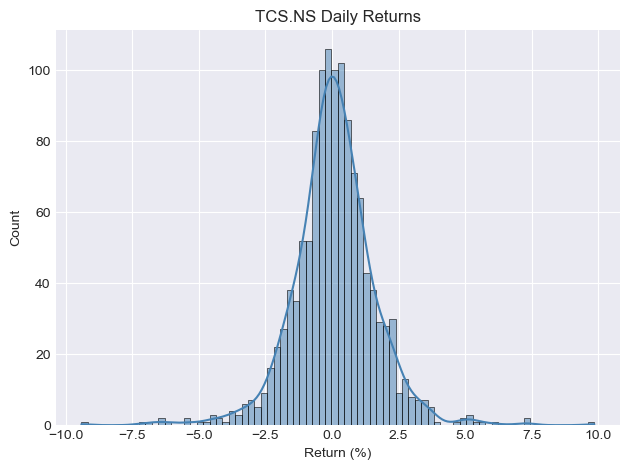

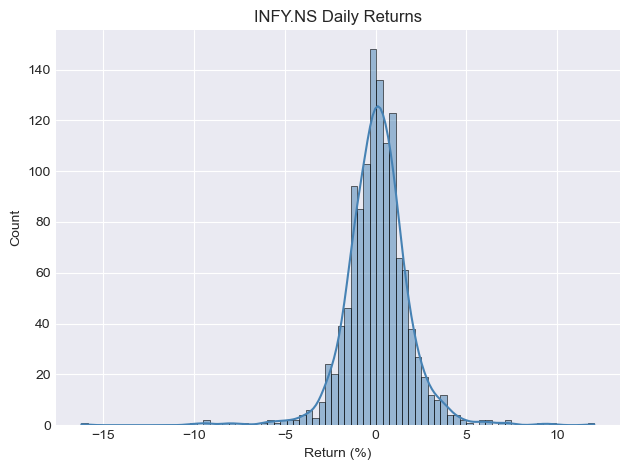

In [74]:
#daily return distributions

for ticker, df in raw.items():
    
    returns = df['Close'].pct_change().dropna() * 100
    sns.histplot(returns, bins=80, kde=True,color='steelblue')
    plt.title(f'{ticker} Daily Returns')
    plt.xlabel('Return (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()



In [76]:
close_prices = pd.DataFrame({
    ticker: df['Close'] for ticker, df in raw.items()
})
returns_all = close_prices.pct_change().dropna()

In [88]:
close_prices

,RELIANCE.NS,TCS.NS,INFY.NS
Date,,,
2019-01-01,496.196381,1561.000610,541.725830
2019-01-02,489.733917,1577.818115,544.984070
2019-01-03,483.691925,1558.662231,545.065613
2019-01-04,486.303436,1539.711426,538.467651
2019-01-07,489.003510,1556.980347,547.142639
...,...,...,...
2023-12-22,1267.243042,3513.734131,1440.279907
2023-12-26,1273.665527,3487.592773,1422.816650
2023-12-27,1278.013184,3501.973145,1444.150391


In [90]:
returns_all

,RELIANCE.NS,TCS.NS,INFY.NS
Date,,,
2019-01-02,-0.013024,0.010774,0.006015
2019-01-03,-0.012337,-0.012141,0.000150
2019-01-04,0.005399,-0.012158,-0.012105
2019-01-07,0.005552,0.011216,0.016111
2019-01-08,-0.000090,-0.002292,-0.002456
...,...,...,...
2023-12-22,0.000976,0.009637,0.017513
2023-12-26,0.005068,-0.007440,-0.012125
2023-12-27,0.003413,0.004123,0.014994


Text(0.5, 1.0, 'Closing Price Correlation')

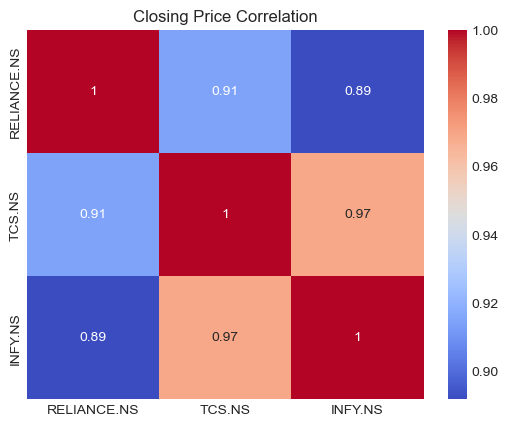

In [100]:
sns.heatmap(close_prices.corr(),annot=True,cmap='coolwarm')
plt.title("Closing Price Correlation")

Text(0.5, 1.0, 'Daily Returns Correlation')

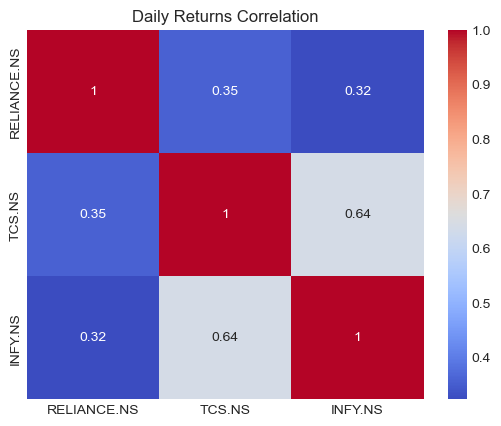

In [102]:
sns.heatmap(returns_all.corr(),annot=True,cmap='coolwarm')
plt.title("Daily Returns Correlation")

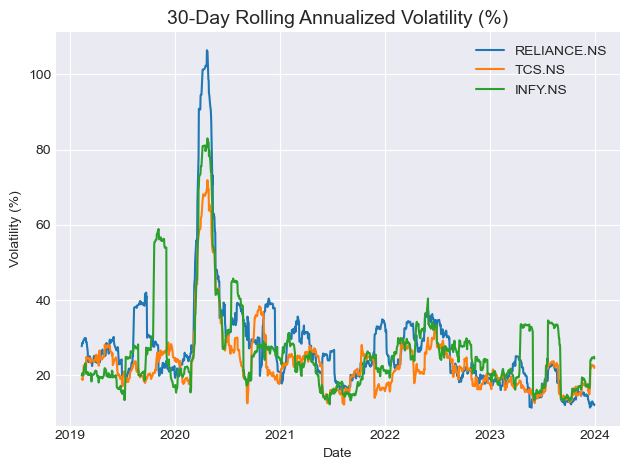

In [110]:

for ticker, df in raw.items():
    #df['returns']=df['close'].pct_change()
    rolling_vol = df['Close'].pct_change().rolling(30).std() * np.sqrt(252) * 100
    sns.lineplot(rolling_vol, label=ticker)

plt.title("30-Day Rolling Annualized Volatility (%)", fontsize=14)
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()
plt.show()



In [114]:
for ticker, df in raw.items():
    fname = ticker.replace(".", "_")
    df.to_csv(f"{fname}_raw.csv",index=False)
    print(f"Saved {fname}_raw.csv")

Saved RELIANCE_NS_raw.csv
Saved TCS_NS_raw.csv
Saved INFY_NS_raw.csv
